In [ ]:
import requests as rq

from openai import OpenAI

from pprint import pprint

import numpy as np

import matplotlib.pyplot     as plt



In [ ]:
'''

'''

In [2]:
BASE_URL = "127.0.0.1:9931"

client = OpenAI(
    base_url=f'http://{BASE_URL}/v1'
    , api_key = 'no-sk'
    )

In [3]:
for _ in range(10):
    r = client.chat.completions.create(
        model='local',
        messages=[
            {"role": "system", "content": "Invent moi le nom d'une voyture Belge"},
            {"role": "user", "content": "Reponds avec un seul mot, sans ponctuation, sans majuscule, sans espace, sans tiret, sans chiffre, sans accent, sans apostrophe, sans tréma, sans cédille, sans point."},
        ],
        max_tokens=7,
        temperature=4.2,
        #seed=3,
        extra_body={'chat_template_kwargs':{'enable_thinking': False}}
    )
    pprint(r.choices[0].message.content)
 


'smurf'
'spartaco'
'flage'
'spira'
'flanelle'
'spoor'
'volvo'
'flana'
'voiture'
'belcar'


In [ ]:
for _ in range(10):
    r = client.chat.completions.create(
        model='local',
        messages=[
            {"role": "system", "content": "Donne moi le nom d une ville belge"},
            {"role": "user", "content": "Reponds avec un seul mot, sans ponctuation, sans majuscule, sans espace, sans tiret, sans chiffre, sans accent, sans apostrophe, sans tréma, sans cédille, sans point."},
        ],
        logprobs=5
        top_ogprobs=True, #probabilite de token plus elevee
        max_tokens=4,
        temperature=1.5,
        #seed=3,
        extra_body={'chat_template_kwargs':{'enable_thinking': False}}
    )

for token in r.choices[0].logprobs.content[0].top_logprobs:
     print(f'{token.token}: {np.exp(token.logprob)*100} %' )

    
 


In [5]:
for _ in range(10):
    r = client.chat.completions.create(
        model="local",
        messages=[
            {"role": "system", "content": "Donne-moi le nom d'une ville belge."},
            {
                "role": "user",
                "content": "Réponds avec un seul mot, sans ponctuation, sans majuscule, sans espace, sans tiret, sans chiffre, sans accent, sans apostrophe, sans tréma, sans cédille, sans point."
            },
        ],
        logprobs=True,
        top_logprobs=5,
        max_tokens=7,
        temperature=1.5,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    for token in r.choices[0].logprobs.content[0].top_logprobs:
        print(f"{token.token}: {np.exp(token.logprob) * 100:.2f}%")

    print("---")

br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---
br: 63.92%
an: 9.13%
g: 8.61%
nam: 1.95%
lie: 1.81%
---


In [9]:
play_img = Path("play-img.jpg")

print(play_img.resolve())
print(play_img.exists())

/home/bm/formation/formation/vLLM/01_open_ai_api/play-img.jpg
False


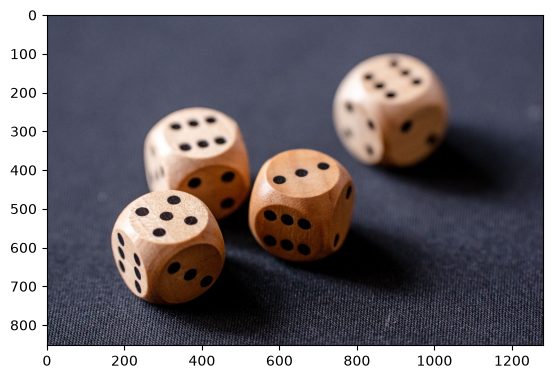

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
play_img= Path("/home/bm/formation/formation/cours_llama/play-img.jpg")
plt.imshow(plt.imread(play_img))
plt.show()


True


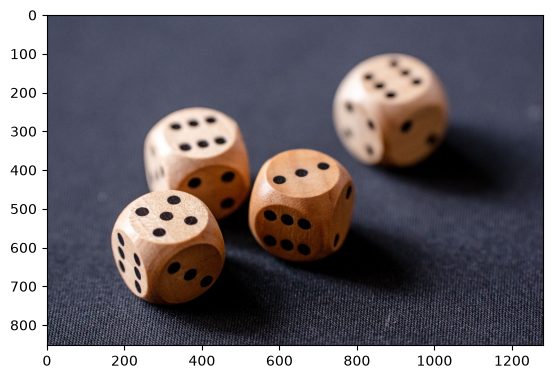

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

play_img = Path("/home/bm/formation/formation/cours_llama/play-img.jpg")

print(play_img.exists())

plt.imshow(plt.imread(play_img))
plt.show()

In [15]:
import base64
base64.b64encode(play_img.read_bytes()).decode()


'...'

In [27]:
b64_play_img = base64.b64encode(
    play_img.read_bytes()
).decode()

r = client.chat.completions.create(
    model="local",

    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Donne-moi Le nombre de cubes, La somme des points et Le descripteur de l image"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_play_img}"
                    }
                }
            ]
        }
    ],

    logprobs=True,
    top_logprobs=5,
    max_tokens=777,
    temperature=1.5,

    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        }
    }
)

print(r.choices[0].message.content)

Based on the image provided, here is the information you requested:

---

✅ **Nombre de cubes (Number of dice):**  
**4 dés en bois** (4 wooden dice)

---

✅ **Somme des points visibles (Sum of visible pips):**

Let’s count the pips on each die carefully:

1. **Die at bottom-left (closest to viewer):**
   - Top face: 5 pips
   - Front face: 6 pips
   - Right face: 3 pips  
   → Total = 5 + 6 + 3 = **14**

2. **Die behind it (middle-left):**
   - Top face: 6 pips
   - Front face: 3 pips
   - (Left side partially visible, but not clearly countable — we’ll only count clearly visible faces)  
   → Visible total = 6 + 3 = **9**

3. **Die in center-right:**
   - Top face: 3 pips
   - Front face: 6 pips
   - Right face: 2 pips  
   → Total = 3 + 6 + 2 = **11**

4. **Die in background (top-right, blurry):**
   - Top face: 6 pips
   - Front face: 3 pips
   - Right face: 2 pips (partially visible, but discernible)  
   → Total = 6 + 3 + 2 = **11**

> ⚠️ Note: We are summing **only the clearly vi

In [ ]:
b64_play_img = base64.b64encode(
    play_img.read_bytes()
).decode()

r = client.chat.completions.create(
    model="local",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": 'C"Donne-moi Le nombre de cubes, La somme des points et Le descripteur de l image".'
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_play_img}"
                    }
                }
            ]
        }
    ],
    max_tokens=300,
    temperature=0.7,
    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        }
    },
    response_format={"type": "json_object"}
)

print(r.choices[0].message.content)



{
  "nombre_de_cubes": 4,
  "somme_des_points": 27,
  "descripteur_de_l_image": "Quatre dés en bois de teinte claire, aux arêtes arrondies, reposent sur une surface sombre et texturée. Trois dés sont au premier plan, nettement visibles, tandis qu'un quatrième est légèrement flou en arrière-plan. Les faces visibles affichent des pips noirs : un dé montre 5, 3 et 6 ; un autre 6, 3 et 2 ; un troisième 3, 6 et 1 ; et le dernier, flou, montre 6, 3 et 5. L'éclairage doux met en valeur la texture du bois et crée de légères ombres portées, donnant une impression de profondeur et de calme."
}


In [ ]:
b64_play_img = base64.b64encode(
    play_img.read_bytes()
).decode()

r = client.chat.completions.create(
    model="local",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": 'C"Donne-moi Le nombre de cubes, La somme des points et Le descripteur de l image"'
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_play_img}"
                    }
                }
            ]
        }
    ],
    max_tokens=30,
    temperature=0.7,
    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        }
    },
    response_format={"type": "json_object"}
)

from json import loads

#data = loads(r.choices[0].message.content)
print(data)
print(repr(r.choices[0].message.content))
print(r.choices[0].finish_reason)


{'somme_points': 25}
'{\n  "Nombre de cubes": 4,\n  "Somme des points": 25,\n  "Descripteur de'
length


In [36]:
from pydantic import BaseModel, Field
from datetime import date
from typing import Literal 

class Play(BaseModel):
    somme_points: int = Field(..., description="La somme des points de l'image")
    numero_cubes: int = Field(..., description="Le nombre de cubes dans l'image")
    descriptor: Literal["play"] = Field("play", description="Le descripteur de l'image, toujours 'play'")
    date_modele: date = Field(..., description="La date du modèle utilisé pour l'analyse de l'image format dd/mm/yyyy")


class Numeraux_chaque_cube(BaseModel):
    somme_points_chaque_cube: int = Field(
        ...,
        description="La somme des points de l'image"
    )

    numero_cubes: int = Field(
        ...,
        description="Le nombre de cubes dans l'image"
    )

    descriptor: Literal["numeraux"] = Field(
        "numeraux",
        description="Le descripteur de l'image, toujours 'numeraux'"
    )

    date_modele: date = Field(
        ...,
        description="La date du modèle utilisé pour l'analyse"
    )

    description_image: str = Field(
        ...,
        description="Description courte de l'image"
    )

    type_objet: Literal["cube", "de", "autre"] = Field(
        ...,
        description="Type d'objet identifié dans l'image"
    )

    confiance: float = Field(
        ...,
        description="Niveau de confiance de l'analyse entre 0 et 1"
    )


Numeraux_chaque_cube.model_json_schema()
    

{'properties': {'somme_points_chaque_cube': {'description': "La somme des points de l'image",
   'title': 'Somme Points Chaque Cube',
   'type': 'integer'},
  'numero_cubes': {'description': "Le nombre de cubes dans l'image",
   'title': 'Numero Cubes',
   'type': 'integer'},
  'descriptor': {'const': 'numeraux',
   'default': 'numeraux',
   'description': "Le descripteur de l'image, toujours 'numeraux'",
   'title': 'Descriptor',
   'type': 'string'},
  'date_modele': {'description': "La date du modèle utilisé pour l'analyse",
   'format': 'date',
   'title': 'Date Modele',
   'type': 'string'},
  'description_image': {'description': "Description courte de l'image",
   'title': 'Description Image',
   'type': 'string'},
  'type_objet': {'description': "Type d'objet identifié dans l'image",
   'enum': ['cube', 'de', 'autre'],
   'title': 'Type Objet',
   'type': 'string'},
  'confiance': {'description': "Niveau de confiance de l'analyse entre 0 et 1",
   'title': 'Confiance',
   'type'

In [41]:
r = client.chat.completions.create(
    model="local",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text", "text": 'Remplis le json selon le schema'
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_play_img}"
                    }
                }
            ]
        }
    ],
    max_tokens=300,
    temperature=0.7,
    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        }
    },
    response_format={"type": "json_schema", 'json_schema': { 'name': 'Numeraux_chaque_cube', 'schema': Numeraux_chaque_cube.model_json_schema() }}
)

from json import loads

# data = loads(r.choices[0].message.content)
# pprint(data)

print(repr(r.choices[0].message.content))
print("finish_reason:", r.choices[0].finish_reason)


'{\n  "somme_points_chaque_cube": 21,\n  "numero_cubes": 4,\n  "date_modele": "2025-10-22",\n  "description_image": "Quatre dés en bois de teinte claire à faces arrondies, posés sur une surface textile sombre, flous en arrière-plan, avec des pips noirs visibles sur les faces supérieures et latérales.",\n  "type_objet": "de",\n  "confiance": 0.98,\n  "descriptor": "numeraux"\n}'
finish_reason: stop


In [43]:
#Numeraux_chaque_cube.model_json_schema(r.choices[0].message.content)

data = Numeraux_chaque_cube.model_validate_json(
    r.choices[0].message.content
)

print(data)



somme_points_chaque_cube=21 numero_cubes=4 descriptor='numeraux' date_modele=datetime.date(2025, 10, 22) description_image='Quatre dés en bois de teinte claire à faces arrondies, posés sur une surface textile sombre, flous en arrière-plan, avec des pips noirs visibles sur les faces supérieures et latérales.' type_objet='de' confiance=0.98


In [44]:
Numeraux_chaque_cube.model_json_schema()

{'properties': {'somme_points_chaque_cube': {'description': "La somme des points de l'image",
   'title': 'Somme Points Chaque Cube',
   'type': 'integer'},
  'numero_cubes': {'description': "Le nombre de cubes dans l'image",
   'title': 'Numero Cubes',
   'type': 'integer'},
  'descriptor': {'const': 'numeraux',
   'default': 'numeraux',
   'description': "Le descripteur de l'image, toujours 'numeraux'",
   'title': 'Descriptor',
   'type': 'string'},
  'date_modele': {'description': "La date du modèle utilisé pour l'analyse",
   'format': 'date',
   'title': 'Date Modele',
   'type': 'string'},
  'description_image': {'description': "Description courte de l'image",
   'title': 'Description Image',
   'type': 'string'},
  'type_objet': {'description': "Type d'objet identifié dans l'image",
   'enum': ['cube', 'de', 'autre'],
   'title': 'Type Objet',
   'type': 'string'},
  'confiance': {'description': "Niveau de confiance de l'analyse entre 0 et 1",
   'title': 'Confiance',
   'type'

Le nombre de cubes dans l image La somme des points de l image" Le descripteur de l image

    

In [48]:
r = client.chat.completions.create(
    model="local",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text", "text": 'Remplis le json selon le schema'
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_play_img}"
                    }
                }
            ]
        }
    ],
    max_tokens=300,
    temperature=0.7,
    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        }
    },
    response_format={"type": "json_schema", 'json_schema': { 'name': 'Play', 'schema': Play.model_json_schema() }}
)

from json import loads

# data = loads(r.choices[0].message.content)
# pprint(data)

print(repr(r.choices[0].message.content))
print("finish_reason:", r.choices[0].finish_reason)


'{\n  "somme_points": 15,\n  "numero_cubes": 4,\n  "date_modele": "2025-06-25",\n  "descriptor": "play"\n}'
finish_reason: stop


In [47]:
Play.model_json_schema()

{'properties': {'somme_points': {'description': "La somme des points de l'image",
   'title': 'Somme Points',
   'type': 'integer'},
  'numero_cubes': {'description': "Le nombre de cubes dans l'image",
   'title': 'Numero Cubes',
   'type': 'integer'},
  'descriptor': {'const': 'play',
   'default': 'play',
   'description': "Le descripteur de l'image, toujours 'play'",
   'title': 'Descriptor',
   'type': 'string'},
  'date_modele': {'description': "La date du modèle utilisé pour l'analyse de l'image format dd/mm/yyyy",
   'format': 'date',
   'title': 'Date Modele',
   'type': 'string'}},
 'required': ['somme_points', 'numero_cubes', 'date_modele'],
 'title': 'Play',
 'type': 'object'}

In [49]:
#Numeraux_chaque_cube.model_json_schema(r.choices[0].message.content)

data = Play.model_validate_json(
    r.choices[0].message.content
)

print(data)



somme_points=15 numero_cubes=4 descriptor='play' date_modele=datetime.date(2025, 6, 25)
